In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
data_dir = "/content/drive/MyDrive/leapGestRecog/leapGestRecog"


In [11]:
import os
print(os.listdir(data_dir)[:10])  # should show folders like 00, 01, 02...


['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [14]:
import cv2
import numpy as np
import os

X, y = [], []
classes = sorted(os.listdir(data_dir))

for label, gesture in enumerate(classes):
    gesture_path = os.path.join(data_dir, gesture)
    if not os.path.isdir(gesture_path):
        continue

    # Walk through all subfolders
    for root, _, files in os.walk(gesture_path):
        for img_name in files:
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(root, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                print("Could not read:", img_path)
                continue

            img = cv2.resize(img, (64, 64))
            X.append(img.flatten())
            y.append(label)

X = np.array(X) / 255.0
y = np.array(y)
print("Dataset shape:", X.shape, "Labels:", len(y))
print("Number of classes:", len(classes))


Dataset shape: (20000, 4096) Labels: 20000
Number of classes: 10


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (16000, 4096) Test size: (4000, 4096)


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=300)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

print("PCA shape:", X_train_scaled.shape, X_test_scaled.shape)


PCA shape: (16000, 300) (4000, 300)


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = SVC(kernel='rbf', gamma='scale', C=10)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.991
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       400
           2       0.96      0.95      0.95       400
           3       1.00      1.00      1.00       400
           4       1.00      1.00      1.00       400
           5       0.95      0.96      0.96       400
           6       1.00      1.00      1.00       400
           7       1.00      1.00      1.00       400
           8       1.00      1.00      1.00       400
           9       1.00      1.00      1.00       400

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

Confusion Matrix:
 [[400   0   0   0   0   0   0   0   0   0]
 [  0 400   0   0   0   0   0   0   0   0]
 [  0   0 379   0   0  21   0   0   0   0]
 [  0   0   0 400   0   0   0   0   0   0]
 [  0   0   0   0 400   0   0   0 

In [18]:
import joblib
joblib.dump(clf, "/content/drive/MyDrive/gesture_model.pkl")
joblib.dump(pca, "/content/drive/MyDrive/pca.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")
np.save("/content/drive/MyDrive/X.npy", X)
np.save("/content/drive/MyDrive/y.npy", y)
print("All artifacts saved to Drive")


All artifacts saved to Drive


In [19]:
import joblib, numpy as np

clf = joblib.load("/content/drive/MyDrive/gesture_model.pkl")
pca = joblib.load("/content/drive/MyDrive/pca.pkl")
scaler = joblib.load("/content/drive/MyDrive/scaler.pkl")
X = np.load("/content/drive/MyDrive/X.npy")
y = np.load("/content/drive/MyDrive/y.npy")


In [23]:
import random

# Pick a random top-level class folder
test_class = random.choice(classes)
gesture_path = os.path.join(data_dir, test_class)

# Walk through subfolders to find images
valid_images = []
for root, _, files in os.walk(gesture_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            valid_images.append(os.path.join(root, f))

if not valid_images:
    raise ValueError("No valid images found in " + gesture_path)

# Choose one image
test_img_path = random.choice(valid_images)
print("Testing with:", test_img_path)

# Load and preprocess
img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Could not read test image at " + test_img_path)

img = cv2.resize(img, (64, 64)).flatten().reshape(1, -1) / 255.0
img_pca = pca.transform(img)
img_scaled = scaler.transform(img_pca)

pred = clf.predict(img_scaled)
print("Predicted class:", classes[pred[0]])


Testing with: /content/drive/MyDrive/leapGestRecog/leapGestRecog/04/08_palm_moved/frame_04_08_0159.png
Predicted class: 04


Testing with: /content/drive/MyDrive/leapGestRecog/leapGestRecog/04/10_down/frame_04_10_0071.png


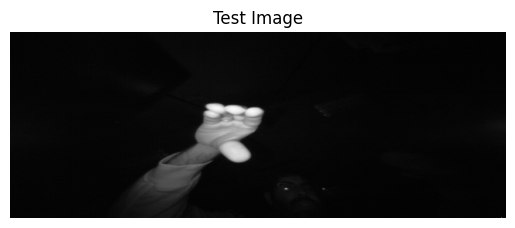

Predicted class: 04


In [24]:
import random
import matplotlib.pyplot as plt

# Pick a random top-level class folder
test_class = random.choice(classes)
gesture_path = os.path.join(data_dir, test_class)

# Walk through subfolders to find images
valid_images = []
for root, _, files in os.walk(gesture_path):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            valid_images.append(os.path.join(root, f))

if not valid_images:
    raise ValueError("No valid images found in " + gesture_path)

# Choose one image
test_img_path = random.choice(valid_images)
print("Testing with:", test_img_path)

# Load and preprocess
img = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Could not read test image at " + test_img_path)

# Show the image
plt.imshow(img, cmap="gray")
plt.title("Test Image")
plt.axis("off")
plt.show()

# Preprocess for model
img = cv2.resize(img, (64, 64)).flatten().reshape(1, -1) / 255.0
img_pca = pca.transform(img)
img_scaled = scaler.transform(img_pca)

pred = clf.predict(img_scaled)
print("Predicted class:", classes[pred[0]])


In [25]:
import joblib, numpy as np

# Save trained model, PCA, and scaler
joblib.dump(clf, "/content/drive/MyDrive/gesture_model.pkl")
joblib.dump(pca, "/content/drive/MyDrive/pca.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/scaler.pkl")

# Save dataset arrays
np.save("/content/drive/MyDrive/X.npy", X)
np.save("/content/drive/MyDrive/y.npy", y)

print("All artifacts saved to Drive")


All artifacts saved to Drive


In [28]:
clf = joblib.load("/content/drive/MyDrive/gesture_model.pkl")
pca = joblib.load("/content/drive/MyDrive/pca.pkl")
scaler = joblib.load("/content/drive/MyDrive/scaler.pkl")
